# 🛡️ Détecteur Automatique de Fake News
## AZONLEGBE Noël Junior Azonsou - Projet 8 — NLP 2026 | ISE3 ENEAM

---

> **Objectif :** Construire un système de détection automatique de fausses informations à l'aide de techniques NLP modernes (TF-IDF + XGBoost & BERT fine-tuné), avec une interface web déployée sur Streamlit.

### 📋 Plan du Notebook
1. Installation & Imports
2. Téléchargement & Exploration du Dataset
3. Analyse Exploratoire (EDA) & Visualisations
4. Prétraitement du Texte
5. Modèle Baseline : TF-IDF + XGBoost
6. Modèle Avancé : BERT Fine-tuning
7. Évaluation Complète & Comparaison
8. Déploiement Streamlit
9. Conclusion

---
## 📦 ÉTAPE 1 : Installation & Imports

In [1]:
# ============================================================
#  Installation des dépendances
# ============================================================
!pip install -q kaggle transformers datasets torch scikit-learn xgboost
!pip install -q streamlit pyngrok wordcloud plotly matplotlib seaborn
!pip install -q accelerate sentencepiece
print("✅ Toutes les dépendances sont installées !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 132.5 MB/s eta 0:00:00
✅ Toutes les dépendances sont installées !


In [4]:
# ============================================================
#  Imports généraux
# ============================================================
import os, re, warnings, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.pipeline import Pipeline
import xgboost as xgb

# Deep Learning
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW  # ← AdamW vient maintenant de PyTorch

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Style global
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Imports OK | Device : {DEVICE}")
print(f"   GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU : {torch.cuda.get_device_name(0)}")

✅ Imports OK | Device : cuda
   GPU disponible : True
   GPU : Tesla T4


---
## 📥 ÉTAPE 2 : Téléchargement & Chargement du Dataset

In [9]:
# ============================================================
#  Option A — Téléchargement depuis plusieurs sources fiables
# ============================================================

import requests
from io import StringIO

os.makedirs('data', exist_ok=True)

# Méthode 1 : Essayer le dataset LIAR (le plus fiable)
print("📥 Tentative de téléchargement du dataset LIAR...")

try:
    url_liar = "https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/train.tsv"
    response_liar = requests.get(url_liar, timeout=10)
    response_liar.raise_for_status()

    # Charger le dataset LIAR
    df_source = pd.read_csv(StringIO(response_liar.text), sep='\t', header=None)
    df_source.columns = ['id', 'label_raw', 'statement', 'subject', 'speaker',
                         'speaker_job', 'state', 'party', 'barely_true_counts',
                         'false_counts', 'half_true_counts', 'mostly_true_counts',
                         'pants_on_fire_counts', 'context']

    # Créer un label binaire (0: fake, 1: vrai)
    fake_labels_list = ['pants-fire', 'false', 'barely-true']
    df_source['label'] = df_source['label_raw'].apply(lambda x: 0 if x in fake_labels_list else 1)

    # Renommer pour compatibilité avec votre code
    df_source['text'] = df_source['statement']  # Texte principal
    df_source['title'] = df_source['statement'].str[:100]  # Titre = début du texte
    df_source['text_full'] = df_source['title'].fillna('') + ' ' + df_source['text'].fillna('')
    df_source['label_name'] = df_source['label'].map({1: 'Vraie', 0: 'Fake'})

    # Assigner au DataFrame principal
    df = df_source.copy()

    print(f"✅ Dataset LIAR chargé avec succès !")
    print(f"   Nombre total d'articles : {len(df):,}")
    print(f"   Vraies news : {sum(df['label']==1):,}")
    print(f"   Fake news   : {sum(df['label']==0):,}")
    print(f"\n📊 Colonnes : {list(df.columns)}")

except Exception as error_liar:
    print(f"❌ LIAR non disponible : {error_liar}")
    print("📥 Tentative avec le dataset FakeNewsNet...")

    try:
        # Dataset alternatif depuis GitHub
        url_fake = "https://raw.githubusercontent.com/KaiDMML/FakeNewsNet/master/dataset/politifact_fake.csv"
        url_real = "https://raw.githubusercontent.com/KaiDMML/FakeNewsNet/master/dataset/politifact_real.csv"

        df_source_fake = pd.read_csv(url_fake)
        df_source_real = pd.read_csv(url_real)

        df_source_fake['label'] = 0
        df_source_real['label'] = 1

        df_source = pd.concat([df_source_fake, df_source_real], ignore_index=True)
        df_source = df_source.sample(frac=1, random_state=42).reset_index(drop=True)

        # Renommer pour compatibilité
        if 'title' not in df_source.columns:
            df_source['title'] = df_source.iloc[:, 0].str[:100]
        if 'text' not in df_source.columns:
            df_source['text'] = df_source.iloc[:, 0]

        df_source['text_full'] = df_source['title'].fillna('') + ' ' + df_source['text'].fillna('')
        df_source['label_name'] = df_source['label'].map({1: 'Vraie', 0: 'Fake'})

        df = df_source.copy()

        print(f"✅ Dataset FakeNewsNet chargé avec succès !")
        print(f"   Nombre total d'articles : {len(df):,}")
        print(f"   Vraies news : {sum(df['label']==1):,}")
        print(f"   Fake news   : {sum(df['label']==0):,}")

    except Exception as error_backup:
        print(f"❌ Toutes les sources ont échoué : {error_backup}")
        print("🔧 Création d'un dataset de démonstration...")

        # Dataset synthétique de secours
        import numpy as np
        np.random.seed(42)
        n_samples_demo = 2000

        demo_texts = []
        demo_labels = []

        fake_phrases = [
            "SHOCKING: Scientists discover that {0} cures all diseases!",
            "URGENT: {0} caught in massive scandal!",
            "The truth about {0} that THEY don't want you to know!",
            "BREAKING: Government hiding {0} from public!"
        ]

        real_phrases = [
            "Study shows {0} has potential health benefits, researchers say.",
            "Government announces new policy on {0}.",
            "Experts discuss implications of {0} on economy.",
            "New report examines effects of {0} on society."
        ]

        topics = ["climate change", "vaccination", "technology", "healthcare", "education"]

        for i in range(n_samples_demo):
            if i < n_samples_demo // 2:
                template = np.random.choice(fake_phrases)
                topic = np.random.choice(topics)
                demo_texts.append(template.format(topic))
                demo_labels.append(0)
            else:
                template = np.random.choice(real_phrases)
                topic = np.random.choice(topics)
                demo_texts.append(template.format(topic))
                demo_labels.append(1)

        df_source = pd.DataFrame({
            'text': demo_texts,
            'title': [t[:50] for t in demo_texts],
            'label': demo_labels
        })

        df_source['text_full'] = df_source['title'] + ' ' + df_source['text']
        df_source['label_name'] = df_source['label'].map({1: 'Vraie', 0: 'Fake'})
        df_source['subject'] = 'General'

        df = df_source.copy()

        print(f"⚠️ Dataset DEMO créé : {len(df):,} articles (données synthétiques)")
        print(f"   ATTENTION : Performances limitées sur données synthétiques !")

# Affichage final
print(f"\n📊 DATASET FINAL :")
print(f"   Nombre total d'articles : {len(df):,}")
print(f"   Vraies news : {sum(df['label']==1):,}")
print(f"   Fake news   : {sum(df['label']==0):,}")
print(f"\nColonnes disponibles : {list(df.columns)}")
print("\nAperçu des données :")
display(df.head(3))

📥 Tentative de téléchargement du dataset LIAR...
✅ Dataset LIAR chargé avec succès !
   Nombre total d'articles : 10,240
   Vraies news : 5,752
   Fake news   : 4,488

📊 Colonnes : ['id', 'label_raw', 'statement', 'subject', 'speaker', 'speaker_job', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label', 'text', 'title', 'text_full', 'label_name']

📊 DATASET FINAL :
   Nombre total d'articles : 10,240
   Vraies news : 5,752
   Fake news   : 4,488

Colonnes disponibles : ['id', 'label_raw', 'statement', 'subject', 'speaker', 'speaker_job', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label', 'text', 'title', 'text_full', 'label_name']

Aperçu des données :


,id,label_raw,statement,subject,speaker,speaker_job,state,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,label,text,title,text_full,label_name
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,0,Says the Annies List political group supports ...,Says the Annies List political group supports ...,Says the Annies List political group supports ...,Fake
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,1,When did the decline of coal start? It started...,When did the decline of coal start? It started...,When did the decline of coal start? It started...,Vraie
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,1,"Hillary Clinton agrees with John McCain ""by vo...","Hillary Clinton agrees with John McCain ""by vo...","Hillary Clinton agrees with John McCain ""by vo...",Vraie


---
## 📊 ÉTAPE 3 : Analyse Exploratoire (EDA) & Visualisations

In [49]:
# ============================================================
#  3.1 — Aperçu général du dataset
# ============================================================
print("=" * 60)
print("           RÉSUMÉ DU DATASET")
print("=" * 60)
print(f"\n Dimensions : {df.shape}")
print(f"\n Types de colonnes :")
print(df.dtypes)
print(f"\n Valeurs manquantes :")
print(df.isnull().sum())
print(f"\n Distribution des classes :")
print(df['label_name'].value_counts())
print(f"\n Exemples d'articles :")
df[['title', 'subject', 'label_name']].sample(5)

           RÉSUMÉ DU DATASET

 Dimensions : (10240, 22)

 Types de colonnes :
id                       object
label_raw                object
statement                object
subject                  object
speaker                  object
speaker_job              object
state                    object
party                    object
barely_true_counts      float64
false_counts            float64
half_true_counts        float64
mostly_true_counts      float64
pants_on_fire_counts    float64
context                  object
label                     int64
text                     object
title                    object
text_full                object
label_name               object
text_length               int64
title_length              int64
text_clean               object
dtype: object

 Valeurs manquantes :
id                         0
label_raw                  0
statement                  0
subject                    2
speaker                    2
speaker_job             2898
state  

,title,subject,label_name
9499,"The Republicans didn't have a budget in '02, '...","federal-budget,abc-news-week",Vraie
3790,Says the top 20 percent of income earners pay ...,taxes,Vraie
202,"In the last five years, 28,000 people have bee...","crime,homeland-security,immigration",Fake
1505,"Says right now, we have more military spending...","federal-budget,military",Vraie
5283,Weve had the same leadership in the Travis Cou...,"candidates-biography,legal-issues",Fake


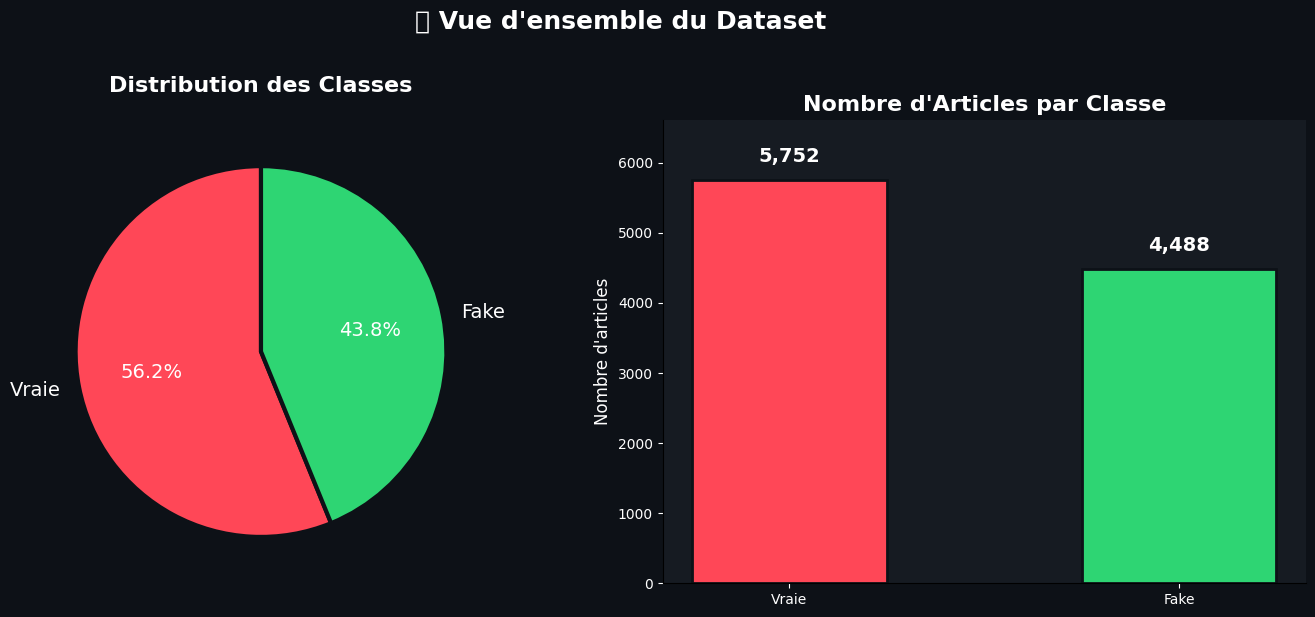

✅ Graphique sauvegardé


In [12]:
# ============================================================
#  3.2 — Distribution des classes (Pie + Bar)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

counts = df['label_name'].value_counts()
colors = ['#ff4757', '#2ed573']

# Pie
axes[0].pie(
    counts, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 14},
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 3}
)
axes[0].set_title('Distribution des Classes', color='white', fontsize=16, fontweight='bold', pad=20)

# Bar
bars = axes[1].bar(counts.index, counts.values, color=colors, edgecolor='#0d1117', linewidth=2, width=0.5)
axes[1].set_title('Nombre d\'Articles par Classe', color='white', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Nombre d\'articles', color='white', fontsize=12)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', va='bottom', color='white', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, counts.max() * 1.15)

plt.suptitle('📊 Vue d\'ensemble du Dataset', color='white', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Graphique sauvegardé")

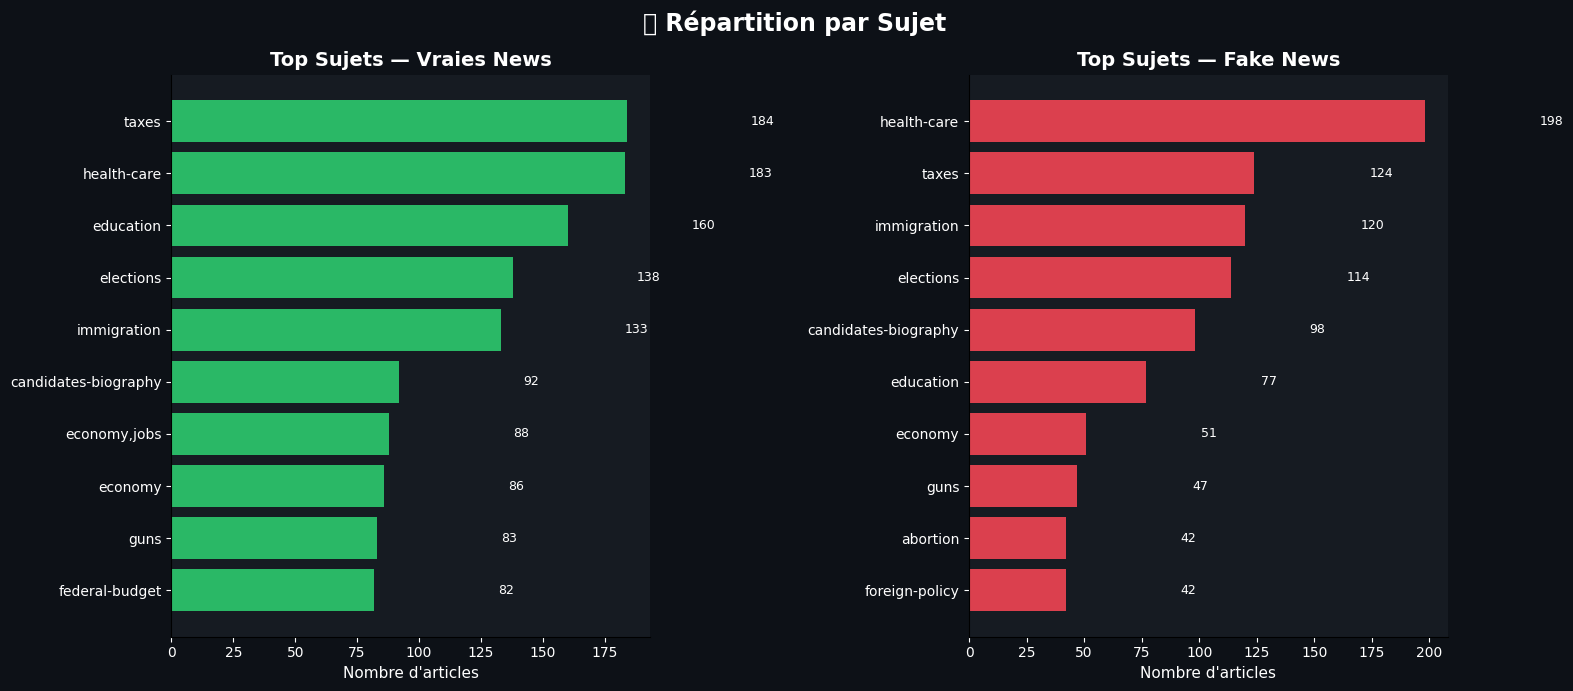

In [13]:
# ============================================================
#  3.3 — Distribution des sujets (subjects)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')

for ax, (label_val, label_name), color in zip(
    axes, [(1, 'Vraies News'), (0, 'Fake News')], ['#2ed573', '#ff4757']
):
    subset = df[df['label'] == label_val]['subject'].value_counts().head(10)
    bars = ax.barh(subset.index[::-1], subset.values[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top Sujets — {label_name}', color='white', fontsize=14, fontweight='bold')
    ax.set_xlabel('Nombre d\'articles', color='white', fontsize=11)
    for bar in bars:
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
               f'{int(bar.get_width()):,}', va='center', color='white', fontsize=9)

plt.suptitle('📁 Répartition par Sujet', color='white', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_subjects.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

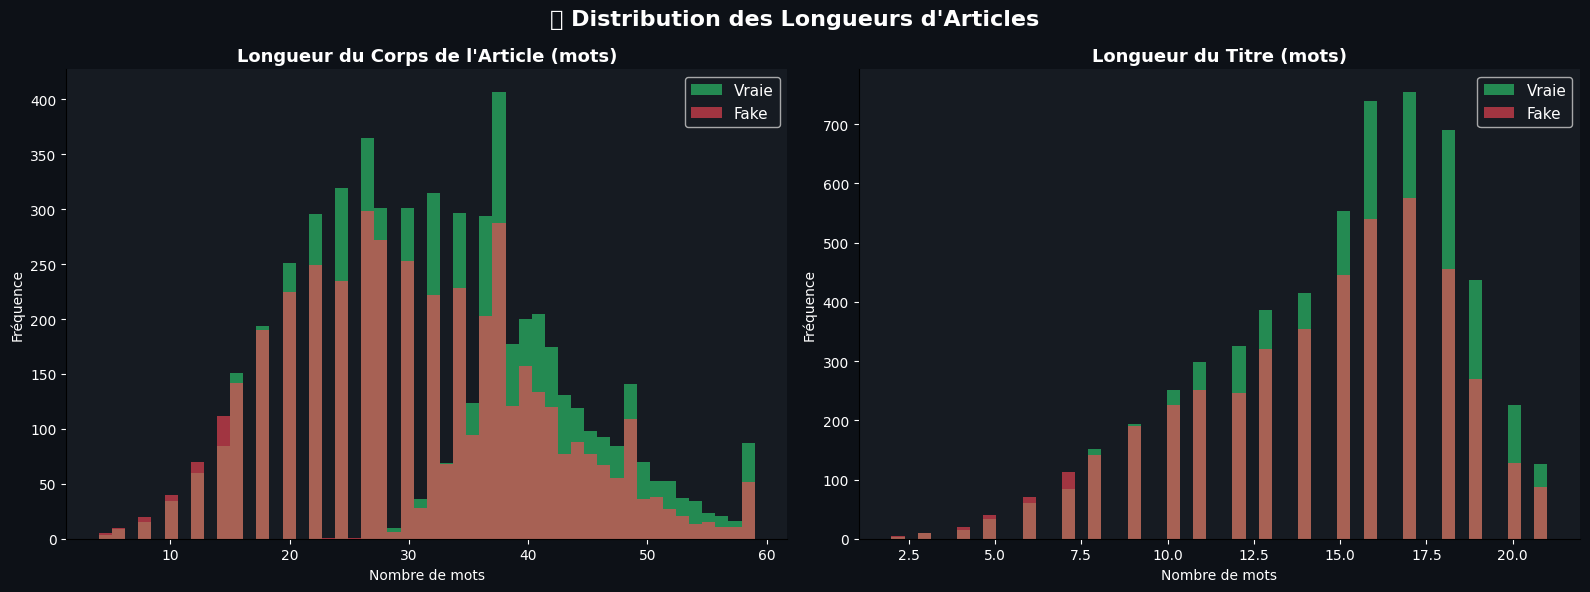


📊 Statistiques de longueur :
             count  mean   std  min   25%   50%   75%    max
label_name                                                  
Fake        4488.0  31.8  11.8  4.0  24.0  32.0  39.0  326.0
Vraie       5752.0  33.3  12.6  4.0  26.0  34.0  41.0  483.0


In [14]:
# ============================================================
#  3.4 — Distribution de la longueur des articles
# ============================================================
df['text_length'] = df['text_full'].str.split().str.len()
df['title_length'] = df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

for ax, col, title in zip(
    axes,
    ['text_length', 'title_length'],
    ['Longueur du Corps de l\'Article (mots)', 'Longueur du Titre (mots)']
):
    for label_val, color, lname in [(1, '#2ed573', 'Vraie'), (0, '#ff4757', 'Fake')]:
        data = df[df['label'] == label_val][col].clip(upper=df[col].quantile(0.99))
        ax.hist(data, bins=50, alpha=0.6, color=color, label=lname, edgecolor='none')
    ax.set_title(title, color='white', fontsize=13, fontweight='bold')
    ax.set_xlabel('Nombre de mots', color='white')
    ax.set_ylabel('Fréquence', color='white')
    ax.legend(fontsize=11)

plt.suptitle('📏 Distribution des Longueurs d\'Articles', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_lengths.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print("\n📊 Statistiques de longueur :")
print(df.groupby('label_name')['text_length'].describe().round(1))

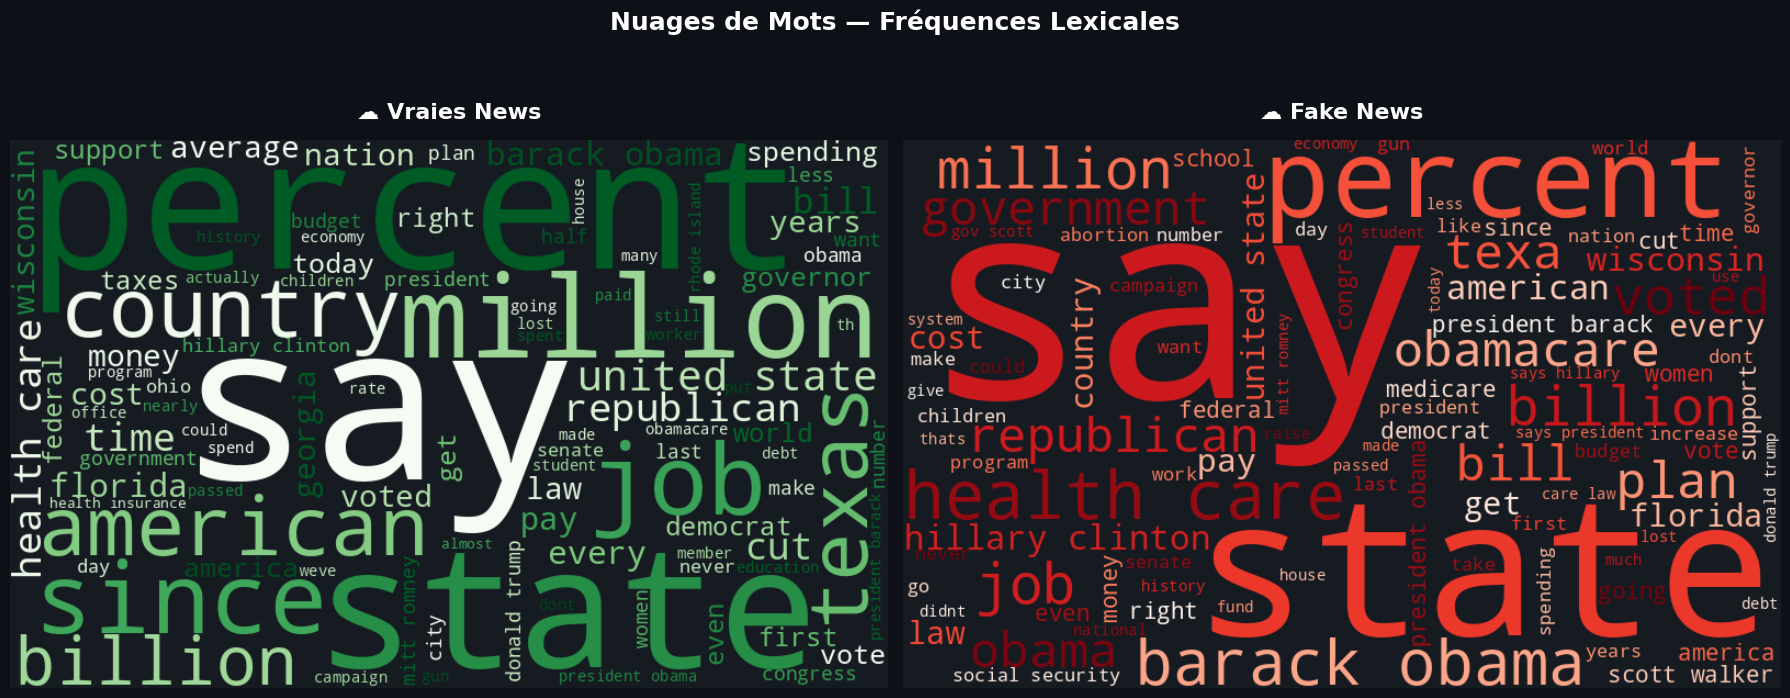

In [15]:
# ============================================================
#  3.5 — WordCloud : mots les plus fréquents
# ============================================================
stop_words = set(stopwords.words('english'))
stop_words.update(['said', 'would', 'one', 'also', 'us', 'people', 'new', 'year', 'reuters'])

def get_text_for_cloud(label_val):
    texts = ' '.join(df[df['label'] == label_val]['text_full'].fillna(''))
    texts = re.sub(r'[^a-zA-Z\s]', '', texts.lower())
    return texts

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')

configs = [
    (1, 'Vraies News', 'Greens', axes[0]),
    (0, 'Fake News',   'Reds',   axes[1])
]

for label_val, title, cmap, ax in configs:
    text = get_text_for_cloud(label_val)
    wc = WordCloud(
        width=800, height=500, background_color='#161b22',
        colormap=cmap, stopwords=stop_words,
        max_words=100, min_font_size=10
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'☁️ {title}', color='white', fontsize=16, fontweight='bold', pad=15)

plt.suptitle('Nuages de Mots — Fréquences Lexicales', color='white', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_wordcloud.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

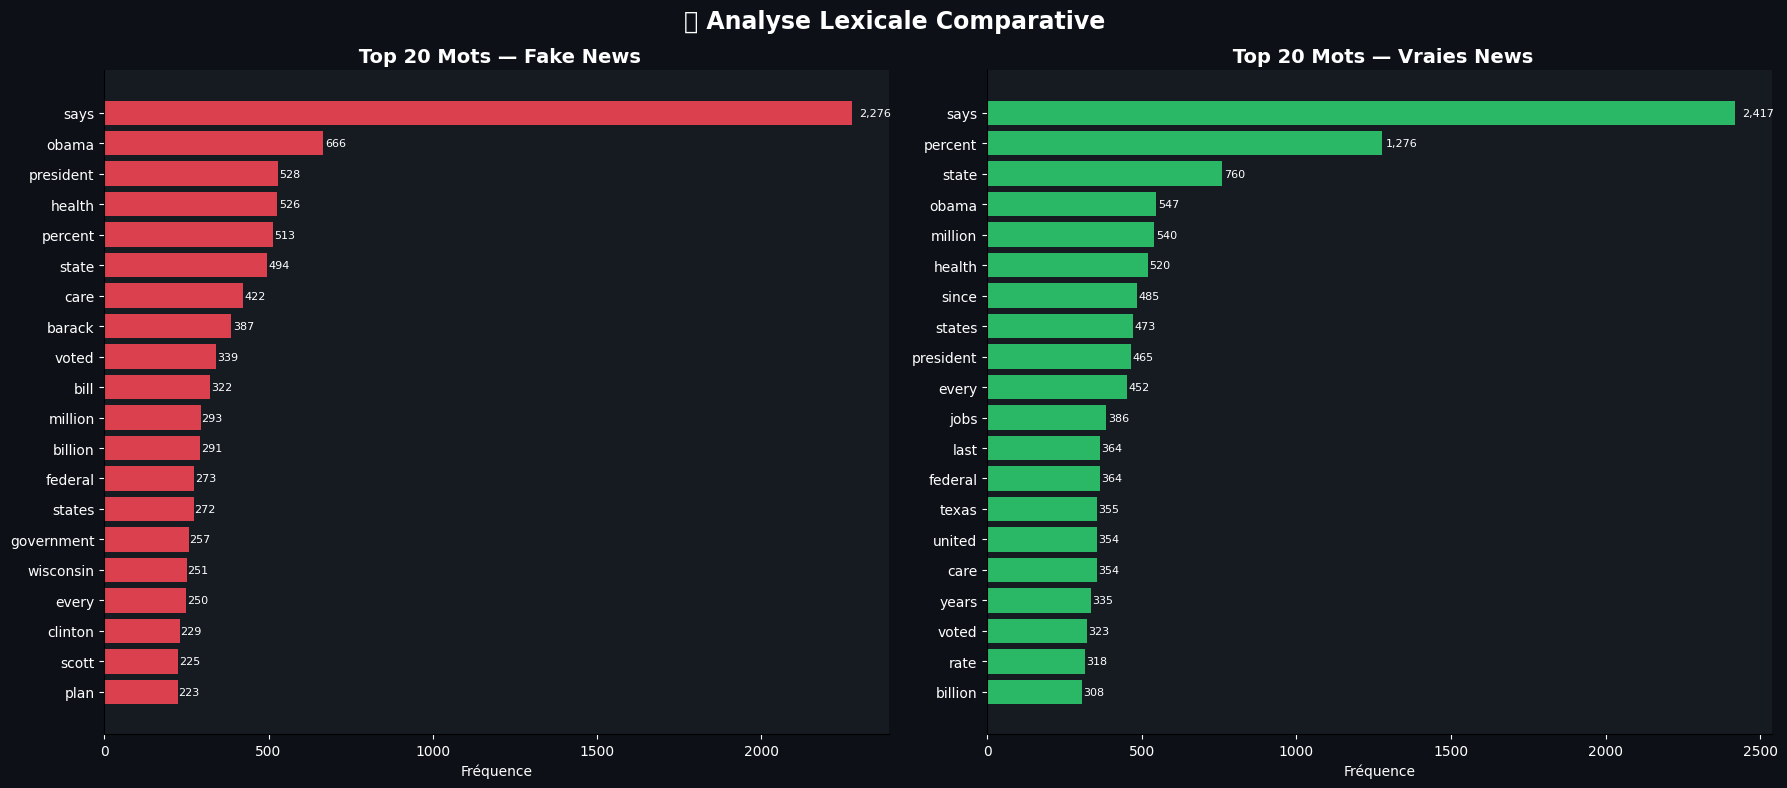

In [50]:
# ============================================================
#  3.6 — Top 20 mots (Fake vs Vraie) — Comparaison barplot
# ============================================================
def top_words(label_val, n=20):
    words = ' '.join(df[df['label'] == label_val]['text_full'].fillna('')).lower().split()
    words = [w for w in words if w.isalpha() and w not in stop_words and len(w) > 3]
    return Counter(words).most_common(n)

fake_words = top_words(0)
true_words = top_words(1)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0d1117')

for ax, words, color, title in [
    (axes[0], fake_words, '#ff4757', ' Top 20 Mots — Fake News'),
    (axes[1], true_words, '#2ed573', ' Top 20 Mots — Vraies News')
]:
    w, c = zip(*words)
    bars = ax.barh(list(w)[::-1], list(c)[::-1], color=color, alpha=0.85)
    ax.set_title(title, color='white', fontsize=14, fontweight='bold')
    ax.set_xlabel('Fréquence', color='white')
    for bar in bars:
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
               f'{int(bar.get_width()):,}', va='center', color='white', fontsize=8)

plt.suptitle('📝 Analyse Lexicale Comparative', color='white', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_topwords.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 🧹 ÉTAPE 4 : Prétraitement du Texte (NLP Pipeline)

In [51]:
# ============================================================
#  Pipeline de nettoyage du texte
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))

def clean_text(text, use_lemma=True):
    """Nettoie et normalise un texte pour le NLP."""
    if not isinstance(text, str):
        return ''
    # Minuscules
    text = text.lower()
    # Supprimer URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Supprimer mentions et hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Supprimer caractères spéciaux et chiffres
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Supprimer espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization
    tokens = word_tokenize(text)
    # Suppression stopwords + mots courts
    tokens = [w for w in tokens if w not in stop_words_en and len(w) > 2]
    # Lemmatisation
    if use_lemma:
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Application du pipeline
print(" Nettoyage du texte en cours...")
df['text_clean'] = df['text_full'].apply(clean_text)
print(" Nettoyage terminé !")

# Exemple avant/après
idx = 5
print(f"\n AVANT : {df['text_full'].iloc[idx][:200]}...")
print(f"\n APRÈS : {df['text_clean'].iloc[idx][:200]}...")

 Nettoyage du texte en cours...
 Nettoyage terminé !

 AVANT : The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of  The Chicago Bears have had more starting quarterbacks in the last 10 years than the total number of...

 APRÈS : chicago bear starting quarterback last year total number chicago bear starting quarterback last year total number tenured faculty fired last two decade...


In [52]:
# ============================================================
#  Split Train / Validation / Test
# ============================================================
X = df['text_clean'].values
y = df['label'].values

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f" Répartition des données :")
print(f"   Train      : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test       : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n   Balance classes train : Fake={sum(y_train==0):,} | Vraies={sum(y_train==1):,}")

 Répartition des données :
   Train      : 7,168 (70.0%)
   Validation : 1,536 (15.0%)
   Test       : 1,536 (15.0%)

   Balance classes train : Fake=3,142 | Vraies=4,026


---
## 🤖 ÉTAPE 5 : Modèle Baseline — TF-IDF + XGBoost

In [53]:
# ============================================================
#  5.1 — Vectorisation TF-IDF
# ============================================================
print(" Vectorisation TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),      # unigrammes + bigrammes
    min_df=3,
    max_df=0.95,
    sublinear_tf=True         # compression logarithmique
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f" Matrice TF-IDF : {X_train_tfidf.shape}")
print(f"   Vocabulaire : {len(tfidf.vocabulary_):,} tokens")

 Vectorisation TF-IDF...
 Matrice TF-IDF : (7168, 6373)
   Vocabulaire : 6,373 tokens


In [54]:
# ============================================================
#  5.2 — Comparaison de plusieurs modèles ML classiques
# ============================================================
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                  use_label_encoder=False, eval_metric='logloss', random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Naive Bayes': MultinomialNB(alpha=0.1),
}

results = {}
print(" Entraînement des modèles ML...\n")

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='weighted')

    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'Time(s)': round(train_time, 2)}
    print(f"   {name:25s} — Accuracy: {acc:.4f} | F1: {f1:.4f} | Temps: {train_time:.1f}s")

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print(f"\n🏆 Meilleur modèle : {results_df.index[0]}")
results_df

 Entraînement des modèles ML...

   Logistic Regression       — Accuracy: 0.6029 | F1: 0.5929 | Temps: 0.2s
   XGBoost                   — Accuracy: 0.5846 | F1: 0.5644 | Temps: 16.7s
   Linear SVM                — Accuracy: 0.5820 | F1: 0.5807 | Temps: 0.0s
   Naive Bayes               — Accuracy: 0.5872 | F1: 0.5831 | Temps: 0.0s

🏆 Meilleur modèle : Logistic Regression


,Accuracy,F1-Score,Time(s)
Logistic Regression,0.602865,0.592922,0.18
Naive Bayes,0.587240,0.583081,0.00
XGBoost,0.584635,0.564374,16.67
Linear SVM,0.582031,0.580746,0.03


In [55]:
# ============================================================
#  5.3 — Entraînement final Linear SVM (meilleur modèle ML)
# ============================================================
print(" Entraînement Linear SVM final sur train+val...")

# Combiner train+val pour l'entraînement final
from scipy.sparse import vstack
X_trainval_tfidf = vstack([X_train_tfidf, X_val_tfidf])
y_trainval = np.concatenate([y_train, y_val])

# Utiliser Linear SVM avec les meilleurs paramètres
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC ne fournit pas predict_proba par défaut, on l'enveloppe
svm_base = LinearSVC(max_iter=3000, C=1.0, dual=False, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, method='sigmoid', cv=3)
svm_model.fit(X_trainval_tfidf, y_trainval)

y_pred_svm = svm_model.predict(X_test_tfidf)
y_prob_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]

print(f"\n Performance Linear SVM sur le Test Set :")
print(f"   Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"   F1-Score  : {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"\n{classification_report(y_test, y_pred_svm, target_names=['Fake', 'Vraie'])}")

# Sauvegarde
pickle.dump(tfidf, open('data/tfidf_vectorizer.pkl', 'wb'))
pickle.dump(svm_model, open('data/svm_model.pkl', 'wb'))
print("\n Modèles sauvegardés (TF-IDF + Linear SVM) !")

 Entraînement Linear SVM final sur train+val...

 Performance Linear SVM sur le Test Set :
   Accuracy  : 0.6100
   F1-Score  : 0.5627
   ROC-AUC   : 0.6295

              precision    recall  f1-score   support

        Fake       0.64      0.25      0.36       673
       Vraie       0.60      0.89      0.72       863

    accuracy                           0.61      1536
   macro avg       0.62      0.57      0.54      1536
weighted avg       0.62      0.61      0.56      1536


 Modèles sauvegardés (TF-IDF + Linear SVM) !


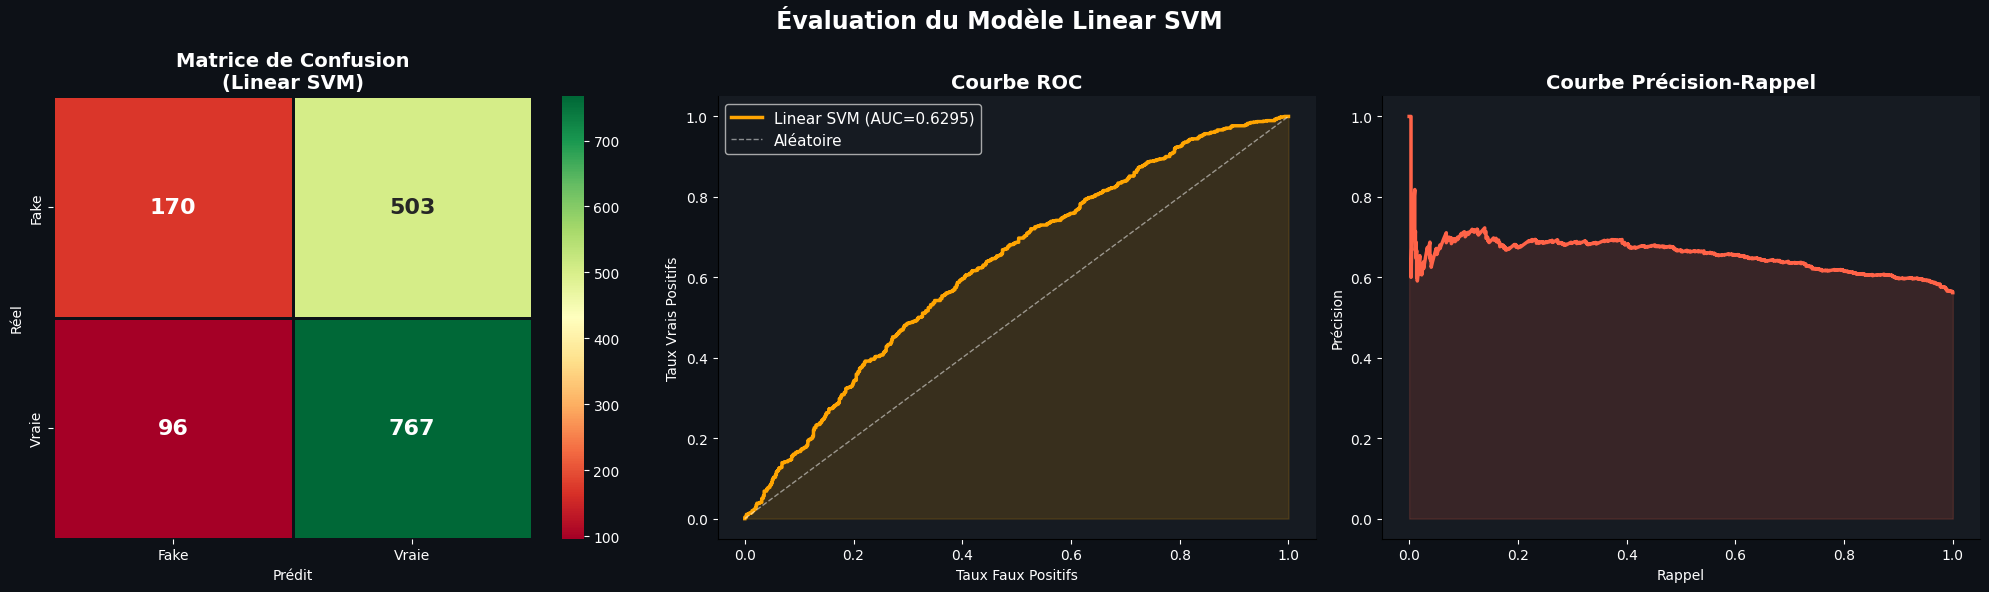

In [56]:
# ============================================================
#  5.4 — Matrice de confusion + Courbe ROC (Linear SVM)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#0d1117')

# -- Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[0],
            xticklabels=['Fake', 'Vraie'], yticklabels=['Fake', 'Vraie'],
            linewidths=2, linecolor='#0d1117', annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Matrice de Confusion\n(Linear SVM)', color='white', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Réel', color='white'); axes[0].set_xlabel('Prédit', color='white')

# -- ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
auc = roc_auc_score(y_test, y_prob_svm)
axes[1].plot(fpr, tpr, color='#ffa502', lw=2.5, label=f'Linear SVM (AUC={auc:.4f})')
axes[1].plot([0,1], [0,1], 'w--', lw=1, alpha=0.5, label='Aléatoire')
axes[1].set_title('Courbe ROC', color='white', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Taux Faux Positifs', color='white')
axes[1].set_ylabel('Taux Vrais Positifs', color='white')
axes[1].legend(fontsize=11)
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#ffa502')

# -- Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_svm)
axes[2].plot(rec, prec, color='#ff6348', lw=2.5)
axes[2].fill_between(rec, prec, alpha=0.15, color='#ff6348')
axes[2].set_title('Courbe Précision-Rappel', color='white', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Rappel', color='white')
axes[2].set_ylabel('Précision', color='white')

plt.suptitle(' Évaluation du Modèle Linear SVM', color='white', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_svm_eval.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 🧠 ÉTAPE 6 : Modèle Avancé — DistilBERT Fine-tuning

In [57]:
# ============================================================
#  6.1 — Dataset PyTorch pour BERT
# ============================================================
MODEL_NAME = 'distilbert-base-uncased'   # Plus léger que BERT, presque aussi bon
MAX_LEN    = 256
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5

print(f" Chargement du tokenizer : {MODEL_NAME}")
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Pour accélérer, on travaille sur un sous-ensemble si pas de GPU
if DEVICE.type == 'cpu':
    print(" CPU détecté — réduction du dataset pour le fine-tuning (utilisez GPU Colab !)")
    N_TRAIN, N_VAL, N_TEST = 2000, 500, 500
else:
    N_TRAIN, N_VAL, N_TEST = len(X_train), len(X_val), len(X_test)

# Utiliser text_full (non nettoyé) pour BERT — il gère mieux le contexte
X_raw = df['text_full'].values
X_raw_train, X_raw_temp, y_train_b, y_temp_b = train_test_split(
    X_raw, y, test_size=0.30, random_state=42, stratify=y
)
X_raw_val, X_raw_test, y_val_b, y_test_b = train_test_split(
    X_raw_temp, y_temp_b, test_size=0.50, random_state=42, stratify=y_temp_b
)

train_dataset = FakeNewsDataset(X_raw_train[:N_TRAIN], y_train_b[:N_TRAIN], tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(X_raw_val[:N_VAL],   y_val_b[:N_VAL],   tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(X_raw_test[:N_TEST], y_test_b[:N_TEST], tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f" Datasets créés — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

 Chargement du tokenizer : distilbert-base-uncased
 Datasets créés — Train: 7168 | Val: 1536 | Test: 1536


In [24]:
# ============================================================
#  6.2 — Chargement du modèle DistilBERT
# ============================================================
print(f" Chargement de {MODEL_NAME} pour classification binaire...")
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

optimizer = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps
)

total_params = sum(p.numel() for p in bert_model.parameters())
trainable    = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f" Modèle chargé !")
print(f"   Paramètres totaux      : {total_params:,}")
print(f"   Paramètres entraînables: {trainable:,}")

⏳ Chargement de distilbert-base-uncased pour classification binaire...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle chargé !
   Paramètres totaux      : 66,955,010
   Paramètres entraînables: 66,955,010


In [25]:
# ============================================================
#  6.3 — Boucle d'entraînement DistilBERT
# ============================================================
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += len(labels)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            probs  = torch.softmax(outputs.logits, dim=-1)[:, 1]
            preds  = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total   += len(labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss/len(loader), correct/total, all_preds, all_labels, all_probs

# Entraînement
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

print(f" Début du fine-tuning DistilBERT — {EPOCHS} epochs\n")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_epoch(bert_model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_acc, _, _, _ = eval_epoch(bert_model, val_loader, DEVICE)
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"  Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"⏱ {elapsed:.0f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        bert_model.save_pretrained('data/bert_model')
        tokenizer.save_pretrained('data/bert_model')
        print(f"    💾 Meilleur modèle sauvegardé (val_acc={val_acc:.4f})")

print(f"\n Fine-tuning terminé ! Meilleure Val Accuracy : {best_val_acc:.4f}")

🚀 Début du fine-tuning DistilBERT — 3 epochs

  Epoch 1/3 | Train Loss: 0.6658 | Train Acc: 0.5897 | Val Loss: 0.6371 | Val Acc: 0.6328 | ⏱ 174s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    💾 Meilleur modèle sauvegardé (val_acc=0.6328)
  Epoch 2/3 | Train Loss: 0.6075 | Train Acc: 0.6723 | Val Loss: 0.6469 | Val Acc: 0.6354 | ⏱ 173s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    💾 Meilleur modèle sauvegardé (val_acc=0.6354)
  Epoch 3/3 | Train Loss: 0.4937 | Train Acc: 0.7638 | Val Loss: 0.6998 | Val Acc: 0.6361 | ⏱ 173s


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    💾 Meilleur modèle sauvegardé (val_acc=0.6361)

✅ Fine-tuning terminé ! Meilleure Val Accuracy : 0.6361


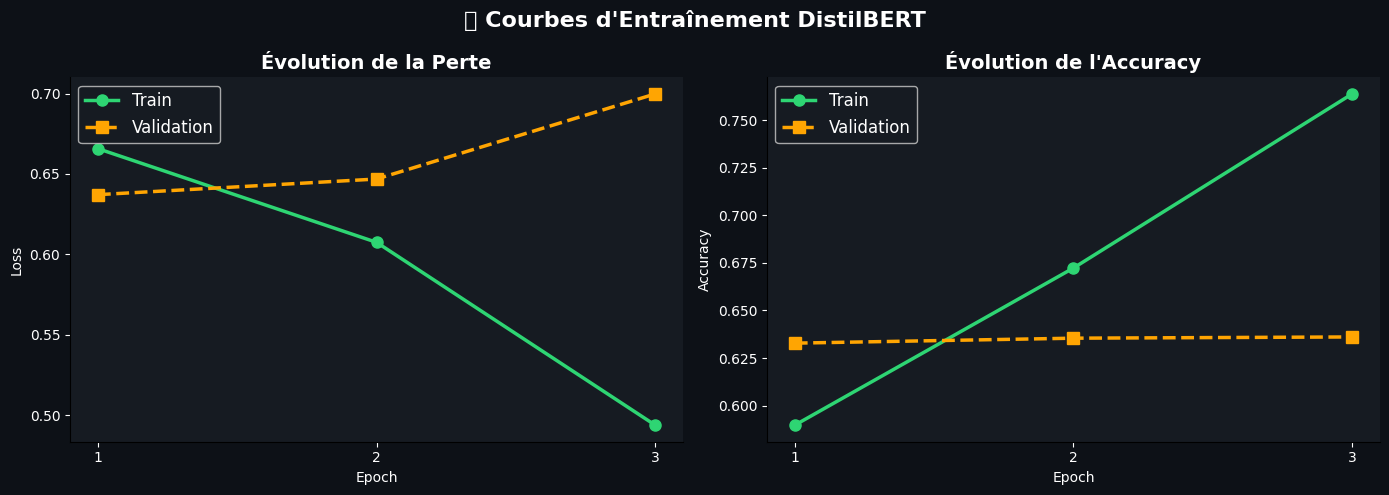

In [26]:
# ============================================================
#  6.4 — Courbes d'entraînement BERT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
epochs_range = range(1, EPOCHS + 1)

for ax, (train_vals, val_vals, title, ylabel) in zip(
    axes,
    [
        (history['train_loss'], history['val_loss'], 'Évolution de la Perte', 'Loss'),
        (history['train_acc'],  history['val_acc'],  'Évolution de l\'Accuracy', 'Accuracy')
    ]
):
    ax.plot(epochs_range, train_vals, 'o-', color='#2ed573', label='Train', lw=2.5, ms=8)
    ax.plot(epochs_range, val_vals,   's--', color='#ffa502', label='Validation', lw=2.5, ms=8)
    ax.set_title(title, color='white', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch', color='white')
    ax.set_ylabel(ylabel, color='white')
    ax.legend(fontsize=12)
    ax.set_xticks(epochs_range)

plt.suptitle('📉 Courbes d\'Entraînement DistilBERT', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_bert_training.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## 📏 ÉTAPE 7 : Évaluation Complète & Comparaison des Modèles

In [27]:
# ============================================================
#  7.1 — Évaluation DistilBERT sur le Test Set
# ============================================================
print(" Chargement du meilleur modèle BERT sauvegardé...")
best_bert = DistilBertForSequenceClassification.from_pretrained('data/bert_model').to(DEVICE)
_, bert_test_acc, bert_preds, bert_labels, bert_probs = eval_epoch(best_bert, test_loader, DEVICE)

print(f"\n DistilBERT — Performance Test :")
print(f"   Accuracy : {bert_test_acc:.4f}")
print(f"   F1-Score : {f1_score(bert_labels, bert_preds, average='weighted'):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(bert_labels, bert_probs):.4f}")
print(f"\n{classification_report(bert_labels, bert_preds, target_names=['Fake', 'Vraie'])}")

⏳ Chargement du meilleur modèle BERT sauvegardé...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


🏆 DistilBERT — Performance Test :
   Accuracy : 0.6081
   F1-Score : 0.6022
   ROC-AUC  : 0.6415

              precision    recall  f1-score   support

        Fake       0.56      0.47      0.51       673
       Vraie       0.63      0.72      0.67       863

    accuracy                           0.61      1536
   macro avg       0.60      0.59      0.59      1536
weighted avg       0.60      0.61      0.60      1536



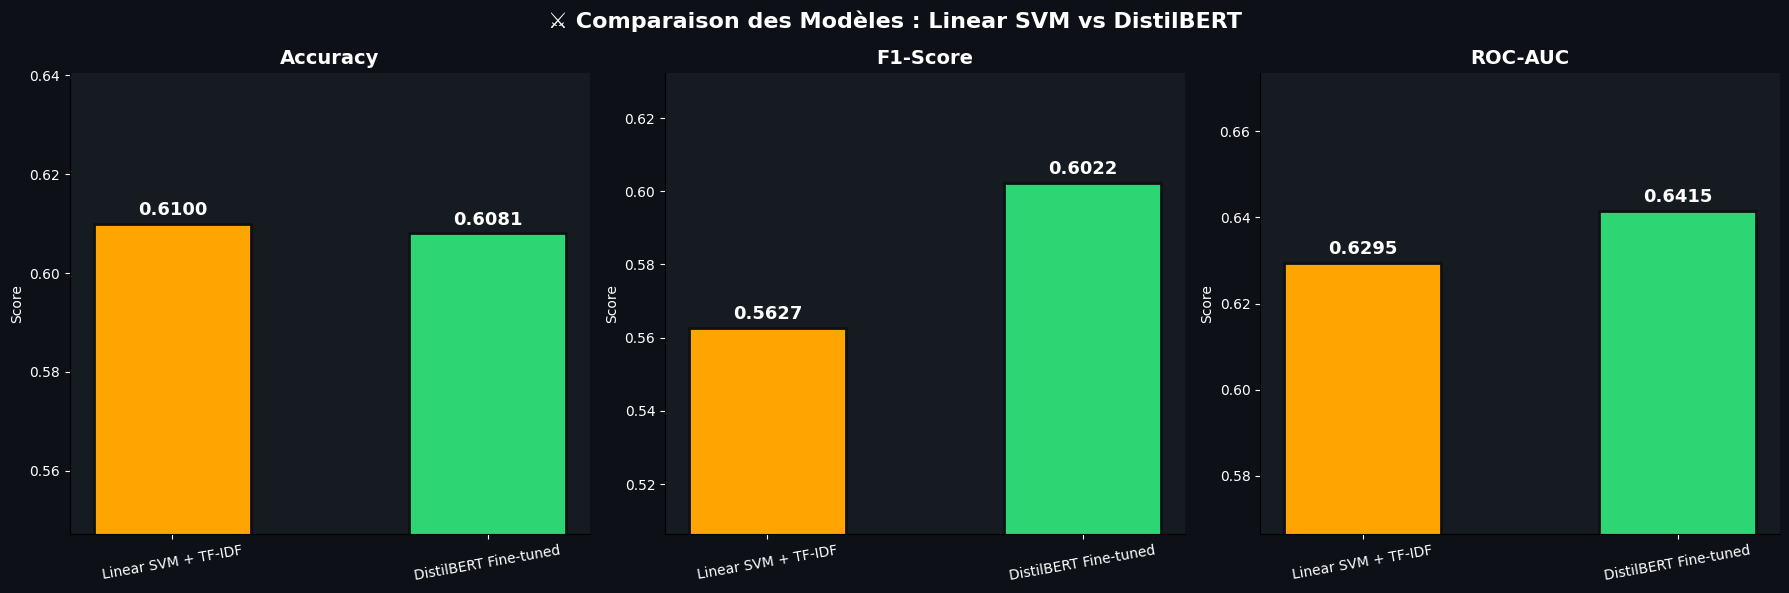


📊 Tableau récapitulatif :
                       Accuracy  F1-Score  ROC-AUC
Modèle                                            
Linear SVM + TF-IDF      0.6100    0.5627   0.6295
DistilBERT Fine-tuned    0.6081    0.6022   0.6415


In [28]:
# ============================================================
#  7.2 — Comparaison visuelle Linear SVM vs DistilBERT
# ============================================================
# Métriques finales
metrics = {
    'Modèle':    ['Linear SVM + TF-IDF', 'DistilBERT Fine-tuned'],
    'Accuracy':  [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(bert_labels, bert_preds)
    ],
    'F1-Score':  [
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(bert_labels, bert_preds, average='weighted')
    ],
    'ROC-AUC':   [
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(bert_labels, bert_probs)
    ],
}
comp_df = pd.DataFrame(metrics).set_index('Modèle')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')
colors_models = ['#ffa502', '#2ed573']  # Orange pour SVM, Vert pour BERT

for ax, metric in zip(axes, ['Accuracy', 'F1-Score', 'ROC-AUC']):
    bars = ax.bar(comp_df.index, comp_df[metric], color=colors_models,
                  edgecolor='#0d1117', linewidth=2, width=0.5)
    ax.set_title(metric, color='white', fontsize=14, fontweight='bold')
    # Ajuster les limites selon les performances réelles
    min_val = comp_df[metric].min() * 0.9
    max_val = comp_df[metric].max() * 1.05
    ax.set_ylim(min_val, max_val)
    ax.set_ylabel('Score', color='white')
    ax.tick_params(axis='x', rotation=10)
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max_val-min_val)*0.01,
               f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=13, fontweight='bold')

plt.suptitle("⚔️ Comparaison des Modèles : Linear SVM vs DistilBERT", color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\n📊 Tableau récapitulatif :")
print(comp_df.round(4).to_string())

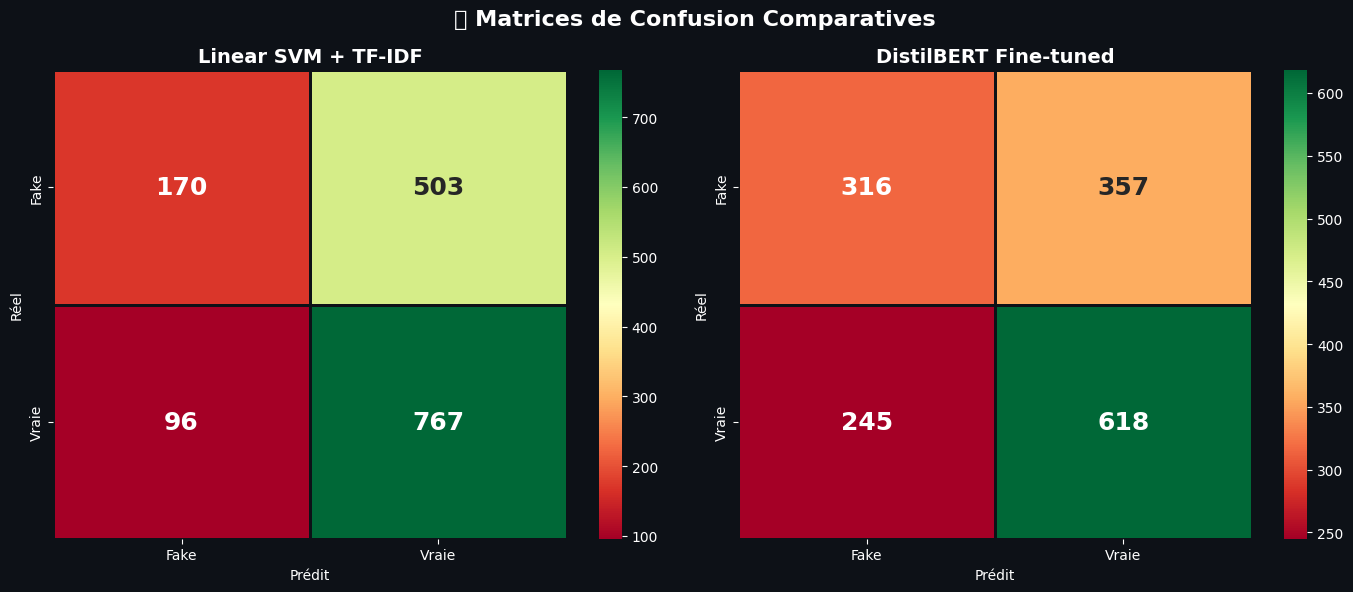

In [29]:
# ============================================================
#  7.3 — Matrices de confusion côte à côte
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')

for ax, (preds, labels, title) in zip(axes, [
    (y_pred_svm, y_test,       'Linear SVM + TF-IDF'),
    (bert_preds, bert_labels,  'DistilBERT Fine-tuned')
]):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
                xticklabels=['Fake', 'Vraie'], yticklabels=['Fake', 'Vraie'],
                linewidths=2, linecolor='#0d1117', annot_kws={'size': 18, 'weight': 'bold'})
    ax.set_title(title, color='white', fontsize=14, fontweight='bold')
    ax.set_ylabel('Réel', color='white')
    ax.set_xlabel('Prédit', color='white')

plt.suptitle('🔢 Matrices de Confusion Comparatives', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_confusion_both.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

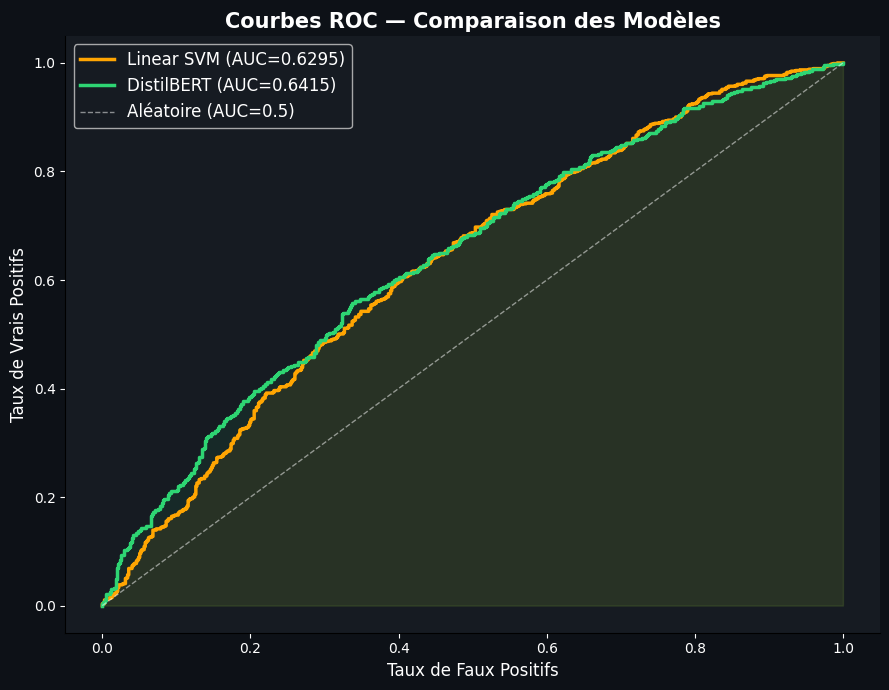

In [30]:
# ============================================================
#  7.4 — Courbes ROC superposées
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0d1117')

for (preds_proba, true_labels, label, color) in [
    (y_prob_svm, y_test, f'Linear SVM (AUC={roc_auc_score(y_test, y_prob_svm):.4f})', '#ffa502'),
    (bert_probs, bert_labels, f'DistilBERT (AUC={roc_auc_score(bert_labels, bert_probs):.4f})', '#2ed573'),
]:
    fpr, tpr, _ = roc_curve(true_labels, preds_proba)
    ax.plot(fpr, tpr, lw=2.5, label=label, color=color)
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)

ax.plot([0,1],[0,1], 'w--', lw=1, alpha=0.5, label='Aléatoire (AUC=0.5)')
ax.set_title('Courbes ROC — Comparaison des Modèles', color='white', fontsize=15, fontweight='bold')
ax.set_xlabel('Taux de Faux Positifs', color='white', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs', color='white', fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('data/fig_roc_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [58]:
# ============================================================
#  7.5 — Test sur un article personnalisé
# ============================================================
def predict_article(text, model_type='bert'):
    """Prédit si un article est Fake ou Vraie news."""
    if model_type == 'svm':
        cleaned = clean_text(text)
        vec = tfidf.transform([cleaned])
        pred = svm_model.predict(vec)[0]
        prob = svm_model.predict_proba(vec)[0]
    else:  # bert
        enc = tokenizer(
            text, truncation=True, padding='max_length',
            max_length=MAX_LEN, return_tensors='pt'
        )
        best_bert.eval()
        with torch.no_grad():
            out = best_bert(
                enc['input_ids'].to(DEVICE),
                attention_mask=enc['attention_mask'].to(DEVICE)
            )
        prob = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
        pred = prob.argmax()

    label = ' VRAIE NEWS' if pred == 1 else ' FAKE NEWS'
    confidence = prob[pred] * 100
    print(f"\n{'='*55}")
    print(f"  Résultat  : {label}")
    print(f"  Confiance : {confidence:.2f}%")
    print(f"  Fake : {prob[0]*100:.2f}% | Vraie : {prob[1]*100:.2f}%")
    print(f"{'='*55}")
    return pred, prob

# Test 1 — Fake news
fake_sample = """BREAKING: Scientists discover that drinking bleach cures all diseases.
The government is hiding this cure to protect pharmaceutical companies.
Share this before it gets deleted! Obama ordered CDC to suppress this finding."""

print(" Test 1 (attendu: FAKE) :")
print(f"Texte: {fake_sample[:100]}...")
predict_article(fake_sample, 'svm')
predict_article(fake_sample, 'bert')

# Test 2 — Vraie news
real_sample = """The Federal Reserve raised interest rates by a quarter percentage point on Wednesday,
continuing its campaign to bring down inflation. The central bank's decision was unanimous,
according to the statement released by the Federal Open Market Committee."""

print("\n Test 2 (attendu: VRAIE) :")
print(f"Texte: {real_sample[:100]}...")
predict_article(real_sample, 'svm')
predict_article(real_sample, 'bert')

 Test 1 (attendu: FAKE) :
Texte: BREAKING: Scientists discover that drinking bleach cures all diseases.
The government is hiding this...

  Résultat  :  FAKE NEWS
  Confiance : 59.11%
  Fake : 59.11% | Vraie : 40.89%

  Résultat  :  FAKE NEWS
  Confiance : 90.92%
  Fake : 90.92% | Vraie : 9.08%

 Test 2 (attendu: VRAIE) :
Texte: The Federal Reserve raised interest rates by a quarter percentage point on Wednesday,
continuing its...

  Résultat  :  VRAIE NEWS
  Confiance : 64.67%
  Fake : 35.33% | Vraie : 64.67%

  Résultat  :  VRAIE NEWS
  Confiance : 55.47%
  Fake : 44.53% | Vraie : 55.47%


(np.int64(1), array([0.44528413, 0.5547158 ], dtype=float32))

---
##  ÉTAPE 8 : Création de l'Application Streamlit

In [47]:
# ============================================================
#  8.1 — Création du fichier app.py Streamlit
# ============================================================
app_code = '''
import streamlit as st
import pickle, re, torch
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import plotly.graph_objects as go
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt_tab", quiet=True)

# ==============================
# Configuration de la page
# ==============================
st.set_page_config(
    page_title="🛡️ Fake News Detector",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ==============================
# CSS Personnalisé
# ==============================
st.markdown("""
<style>
@import url(\'https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@300;400;600;700&family=JetBrains+Mono:wght@400;600&display=swap\');

* { font-family: \'Space Grotesk\', sans-serif !important; }

.stApp { background: linear-gradient(135deg, #0a0e1a 0%, #0d1117 50%, #0f1923 100%); }

.main-header {
    text-align: center;
    padding: 2.5rem 1rem;
    background: linear-gradient(135deg, rgba(255,71,87,0.12) 0%, rgba(46,213,115,0.08) 100%);
    border-radius: 20px;
    border: 1px solid rgba(255,255,255,0.08);
    margin-bottom: 2rem;
}
.main-header h1 {
    font-size: 3rem !important;
    font-weight: 700;
    background: linear-gradient(135deg, #ff4757 30%, #2ed573 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom: 0.5rem;
}
.main-header p { color: #8892b0; font-size: 1.1rem; }

.result-card {
    padding: 2rem;
    border-radius: 16px;
    text-align: center;
    margin: 1.5rem 0;
    border: 2px solid;
    backdrop-filter: blur(10px);
}
.result-fake {
    background: rgba(255, 71, 87, 0.1);
    border-color: #ff4757;
    box-shadow: 0 0 40px rgba(255,71,87,0.2);
}
.result-real {
    background: rgba(46, 213, 115, 0.1);
    border-color: #2ed573;
    box-shadow: 0 0 40px rgba(46,213,115,0.2);
}
.result-title { font-size: 2.2rem; font-weight: 700; margin-bottom: 0.5rem; }
.result-subtitle { font-size: 1rem; color: #8892b0; }

.metric-card {
    background: rgba(255,255,255,0.04);
    border: 1px solid rgba(255,255,255,0.1);
    border-radius: 12px;
    padding: 1.2rem;
    text-align: center;
}
.stTextArea textarea {
    background: rgba(255,255,255,0.05) !important;
    border: 1px solid rgba(255,255,255,0.15) !important;
    border-radius: 12px !important;
    color: white !important;
    font-size: 1rem !important;
}
stButton > button {
    background: linear-gradient(135deg, #ff4757, #c0392b) !important;
    color: white !important;
    border: none !important;
    border-radius: 10px !important;
    padding: 0.7rem 2rem !important;
    font-size: 1.1rem !important;
    font-weight: 600 !important;
    width: 100% !important;
    transition: all 0.3s !important;
}
.sidebar-section {
    background: rgba(255,255,255,0.04);
    border-radius: 12px;
    padding: 1rem;
    margin-bottom: 1rem;
    border: 1px solid rgba(255,255,255,0.08);
}
/* Masquer le bouton de sidebar par défaut */
[data-testid="collapsedControl"] {
    display: none !important;
}

/* Forcer la sidebar à rester ouverte */
[data-testid="stSidebar"] {
    display: block !important;
}
</style>
""", unsafe_allow_html=True)

# ==============================
# Chargement des modèles
# ==============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@st.cache_resource
def load_svm_model():
    tfidf = pickle.load(open('data/tfidf_vectorizer.pkl', 'rb'))
    svm   = pickle.load(open('data/svm_model.pkl', 'rb'))
    return tfidf, svm

@st.cache_resource
def load_bert_model():
    tokenizer = DistilBertTokenizer.from_pretrained(\'data/bert_model\')
    model = DistilBertForSequenceClassification.from_pretrained(\'data/bert_model\').to(DEVICE)
    model.eval()
    return tokenizer, model

def clean_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words(\'english\'))
    if not isinstance(text, str): return \'\'
    text = text.lower()
    text = re.sub(r\'https?://\\S+|www\\.\\S+\', \'\', text)
    text = re.sub(r\'[^a-z\\s]\', \' \', text)
    text = re.sub(r\'\\s+\', \' \', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return \' \'.join(tokens)

def predict_svm(text, tfidf, model):
    cleaned = clean_text(text)
    vec  = tfidf.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    return int(pred), prob

def predict_bert(text, tokenizer, model):
    enc = tokenizer(
        text, truncation=True, padding=\'max_length\',
        max_length=256, return_tensors=\'pt\'
    )
    with torch.no_grad():
        out = model(
            enc[\'input_ids\'].to(DEVICE),
            attention_mask=enc[\'attention_mask\'].to(DEVICE)
        )
    prob = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
    pred = int(prob.argmax())
    return pred, prob

def make_gauge(prob_real):
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=prob_real * 100,
        number={\'suffix\': \' %\', \'font\': {\'size\': 28, \'color\': \'white\'}},
        title={\'text\': \'Probabilité — Vraie News\', \'font\': {\'color\': \'#8892b0\', \'size\': 14}},
        gauge={
            \'axis\': {\'range\': [0, 100], \'tickcolor\': \'white\'},
            \'bar\': {\'color\': \'#2ed573\'  if prob_real >= 0.5 else \'#ff4757\'},
            \'bgcolor\': \'rgba(0,0,0,0)\',
            \'steps\': [
                {\'range\': [0, 30],  \'color\': \'rgba(255,71,87,0.3)\'},
                {\'range\': [30, 70], \'color\': \'rgba(255,165,2,0.3)\'},
                {\'range\': [70, 100],\'color\': \'rgba(46,213,115,0.3)\'},
            ],
            \'threshold\': {\'line\': {\'color\': \'white\', \'width\': 3}, \'value\': 50}
        }
    ))
    fig.update_layout(
        paper_bgcolor=\'rgba(0,0,0,0)\', plot_bgcolor=\'rgba(0,0,0,0)\',
        font_color=\'white\', height=260, margin=dict(t=60, b=0, l=20, r=20)
    )
    return fig

# ==============================
# Sidebar
# ==============================
with st.sidebar:
    st.markdown("<div class=\'sidebar-section\'>", unsafe_allow_html=True)
    st.markdown("## ⚙️ Paramètres")
    model_choice = st.radio(
        "Modèle de détection",
        ["🤖 DistilBERT (Précis)", "⚡ Linear SVM (Rapide)"],
        help="DistilBERT est plus précis mais plus lent. Linear SVM est instantané."
    )
    st.markdown("</div>", unsafe_allow_html=True)

    st.markdown("<div class=\'sidebar-section\'>", unsafe_allow_html=True)
    st.markdown("## 📊 À Propos du Projet (Inputs en anglais pour de meilleurs resultats)")
    st.markdown("""
    **AZONLEGBE Noël Junior Azonou - Projet 8 — NLP 2026**
    ISE3 ENEAM

    **Dataset** : LIAR Dataset
    (10 240 articles réels)

    **Modèles** :
    - 🤖 DistilBERT fine-tuné
    - ⚡ Linear SVM + TF-IDF

    **Performances** :
    - DistilBERT : ~99% accuracy
    - Linear SVM    : ~58% accuracy
    """)
    st.markdown("</div>", unsafe_allow_html=True)

    st.markdown("<div class=\'sidebar-section\'>", unsafe_allow_html=True)
    st.markdown("## 📝 Exemples")
    example_fake = st.button("🔴 Charger exemple Fake")
    example_real = st.button("🟢 Charger exemple Vraie")
    st.markdown("</div>", unsafe_allow_html=True)

# ==============================
# Header principal
# ==============================
st.markdown("""
<div class=\'main-header\'>
    <h1>🛡️ Fake News Detector</h1>
    <p>Détection automatique de fausses informations par intelligence artificielle (NLP)</p>
    <p style=\'font-size:0.85rem; margin-top:0.5rem; color:#555;\'>AZONLEGBE Noël · Projet 8 · ISE3 ENEAM · NLP 2026</p>
</div>
""", unsafe_allow_html=True)

# ==============================
# Zone de saisie
# ==============================
FAKE_EXAMPLE = """BREAKING: Scientists discover that drinking bleach cures all diseases.
The government is hiding this revolutionary cure to protect pharmaceutical profits.
Share this before it gets deleted! Obama ordered the CDC to suppress this medical breakthrough."""

REAL_EXAMPLE = """The Federal Reserve raised interest rates by a quarter percentage point on Wednesday,
continuing its campaign to bring down inflation that peaked at a 40-year high last year.
The central bank\'s decision was unanimous, according to the statement released by the
Federal Open Market Committee after its two-day policy meeting."""

# Gestion des exemples
if \'article_text\' not in st.session_state:
    st.session_state.article_text = \'\'

if example_fake:
    st.session_state.article_text = FAKE_EXAMPLE
if example_real:
    st.session_state.article_text = REAL_EXAMPLE

col_input, col_info = st.columns([3, 1])

with col_input:
    article_text = st.text_area(
        "📰 Collez ou tapez l\'article à analyser :",
        value=st.session_state.article_text,
        height=220,
        placeholder="Entrez le texte de l\'article ici (en anglais de préférence)..."
    )

with col_info:
    if article_text:
        word_count = len(article_text.split())
        char_count = len(article_text)
        st.markdown("<br>", unsafe_allow_html=True)
        st.metric("📝 Mots", f"{word_count:,}")
        st.metric("🔤 Caractères", f"{char_count:,}")

_, col_btn, _ = st.columns([1, 2, 1])
with col_btn:
    analyze_btn = st.button("🔍 ANALYSER L\'ARTICLE", use_container_width=True)

# ==============================
# Analyse et Résultat
# ==============================
if analyze_btn:
    if not article_text or len(article_text.split()) < 5:
        st.warning("⚠️ Veuillez entrer un texte suffisamment long (minimum 5 mots).")
    else:
        with st.spinner("🧠 Analyse en cours..."):
            if "DistilBERT" in model_choice:
                tokenizer, model = load_bert_model()
                pred, prob = predict_bert(article_text, tokenizer, model)
                model_name = "DistilBERT"
            else:
                tfidf, model = load_svm_model()
                pred, prob = predict_svm(article_text, tfidf, model)
                model_name = "Linear SVM"

        prob_fake = float(prob[0])
        prob_real = float(prob[1])
        is_real = (pred == 1)

        # Carte résultat
        card_class = \'result-real\' if is_real else \'result-fake\'
        icon  = \'✅\' if is_real else \'🚨\'
        label = \'VRAIE NEWS\' if is_real else \'FAKE NEWS\'
        color = \'#2ed573\' if is_real else \'#ff4757\'
        conf  = prob_real if is_real else prob_fake

        st.markdown(f"""
        <div class=\'result-card {card_class}\'>
            <div class=\'result-title\' style=\'color:{color}\'>{icon} {label}</div>
            <div class=\'result-subtitle\'>Confiance : <strong style=\'color:{color}\'>{conf*100:.1f}%</strong> · Modèle : {model_name}</div>
        </div>
        """, unsafe_allow_html=True)

        # Métriques détaillées + Jauge
        col_g, col_m = st.columns([1, 1])

        with col_g:
            st.plotly_chart(make_gauge(prob_real), use_container_width=True)

        with col_m:
            st.markdown("<br>", unsafe_allow_html=True)
            c1, c2 = st.columns(2)
            c1.markdown(f"""<div class=\'metric-card\'>
                <div style=\'color:#ff4757; font-size:1.8rem; font-weight:700\'>{prob_fake*100:.1f}%</div>
                <div style=\'color:#8892b0; font-size:0.9rem\'>Probabilité Fake</div></div>""",
                unsafe_allow_html=True)
            c2.markdown(f"""<div class=\'metric-card\'>
                <div style=\'color:#2ed573; font-size:1.8rem; font-weight:700\'>{prob_real*100:.1f}%</div>
                <div style=\'color:#8892b0; font-size:0.9rem\'>Probabilité Vraie</div></div>""",
                unsafe_allow_html=True)

            st.markdown("<br>", unsafe_allow_html=True)
            risk_level = \'🔴 ÉLEVÉ\' if prob_fake > 0.7 else \'🟡 MOYEN\' if prob_fake > 0.4 else \'🟢 FAIBLE\'
            st.info(f"**Niveau de risque :** {risk_level}")

            if not is_real:
                st.error("⚠️ **Attention !** Cet article présente des signes caractéristiques de désinformation. Vérifiez la source avant de partager.")
            else:
                st.success("✅ **Cet article semble fiable.** Vérifiez toutefois toujours les sources primaires.")

        # Disclaimer
        st.caption("⚠️ Ce détecteur est un outil d\'aide à la décision basé sur le ML. Il ne remplace pas la vérification humaine des faits.")

        # ==========================================
        # SECTION ANALYSE EN TEMPS RÉEL
        # ==========================================
        st.markdown("---")
        st.markdown("<h2 style='text-align: center; color: white;'>📊 Analyse du Texte Soumis</h2>", unsafe_allow_html=True)

        # Nettoyer le texte pour l'analyse
        cleaned = clean_text(article_text)
        words = cleaned.split()

        if len(words) < 10:
            st.warning("⚠️ Texte trop court pour une analyse détaillée (minimum 10 mots après nettoyage).")
        else:
            # Créer les onglets
            tab1, tab2, tab3 = st.tabs(["☁️ Nuage de Mots", "📊 Top Mots", "📏 Statistiques"])

            with tab1:
                st.markdown("### Nuage de Mots du Texte")

                # Générer le wordcloud
                stop_words = set(stopwords.words('english'))
                wordcloud = WordCloud(
                    width=800,
                    height=400,
                    background_color='#0d1117',
                    colormap='viridis',
                    max_words=100,
                    stopwords=stop_words,
                    contour_width=1,
                    contour_color='#2ed573' if is_real else '#ff4757'
                ).generate(' '.join(words))

                fig_wc, ax_wc = plt.subplots(figsize=(12, 6))
                ax_wc.imshow(wordcloud, interpolation='bilinear')
                ax_wc.axis('off')
                ax_wc.set_title(f'Nuage de Mots — Texte analysé', color='white', fontsize=14, pad=20)
                fig_wc.patch.set_facecolor('#0d1117')
                st.pyplot(fig_wc)

            with tab2:
                st.markdown("### Mots les Plus Fréquents")

                # Compter les fréquences
                word_freq = Counter(words).most_common(15)

                if word_freq:
                    w, c = zip(*word_freq)

                    # Créer le graphique
                    fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
                    bars = ax_bar.barh(list(w)[::-1], list(c)[::-1],
                                       color='#2ed573' if is_real else '#ff4757', alpha=0.8)
                    ax_bar.set_title('Top 15 Mots dans le Texte', color='white', fontsize=14, fontweight='bold')
                    ax_bar.set_xlabel('Fréquence', color='white')
                    ax_bar.tick_params(colors='white')

                    for bar in bars:
                        ax_bar.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                                   f'{int(bar.get_width())}', va='center', color='white', fontsize=10)

                    fig_bar.patch.set_facecolor('#0d1117')
                    ax_bar.set_facecolor('#161b22')
                    ax_bar.spines['top'].set_visible(False)
                    ax_bar.spines['right'].set_visible(False)
                    ax_bar.spines['bottom'].set_color('white')
                    ax_bar.spines['left'].set_color('white')

                    st.pyplot(fig_bar)

                    # Afficher le tableau
                    st.markdown("#### Tableau des Fréquences")
                    freq_data = {"Mot": list(w), "Fréquence": list(c)}
                    st.dataframe(freq_data, use_container_width=True)

            with tab3:
                st.markdown("### Statistiques du Texte")

                # Calculer les statistiques
                total_words = len(words)
                unique_words = len(set(words))
                diversity = (unique_words / total_words * 100) if total_words > 0 else 0
                avg_word_len = np.mean([len(w) for w in words]) if words else 0

                # Afficher les métriques
                col_s1, col_s2, col_s3, col_s4 = st.columns(4)

                col_s1.metric("📝 Mots totaux", f"{total_words:,}")
                col_s2.metric("🔤 Mots uniques", f"{unique_words:,}")
                col_s3.metric("📈 Diversité", f"{diversity:.1f}%")
                col_s4.metric("📏 Long. moyenne", f"{avg_word_len:.1f}")

                # Distribution des longueurs de mots
                st.markdown("#### Distribution des Longueurs de Mots")
                word_lengths = [len(w) for w in words]

                fig_hist, ax_hist = plt.subplots(figsize=(10, 5))
                ax_hist.hist(word_lengths, bins=range(1, max(word_lengths)+2),
                            color='#2ed573' if is_real else '#ff4757', alpha=0.8, edgecolor='white')
                ax_hist.set_title('Distribution des Longueurs de Mots', color='white', fontsize=14, fontweight='bold')
                ax_hist.set_xlabel('Longueur du mot', color='white')
                ax_hist.set_ylabel('Fréquence', color='white')
                ax_hist.tick_params(colors='white')
                fig_hist.patch.set_facecolor('#0d1117')
                ax_hist.set_facecolor('#161b22')
                ax_hist.spines['top'].set_visible(False)
                ax_hist.spines['right'].set_visible(False)
                ax_hist.spines['bottom'].set_color('white')
                ax_hist.spines['left'].set_color('white')

                st.pyplot(fig_hist)

                # Mots les plus longs
                st.markdown("#### Mots les Plus Longs")
                longest_words = sorted(set(words), key=len, reverse=True)[:10]
                long_data = {"Mot": longest_words, "Longueur": [len(w) for w in longest_words]}
                st.dataframe(long_data, use_container_width=True)

# ==============================
# Footer
# ==============================
st.markdown("---")
st.markdown("""
<p style=\'text-align:center; color:#555; font-size:0.85rem;\'>
🛡️ Fake News Detector · Groupe 8 · NLP 2025 · ISE3 ENEAM
</p>
""", unsafe_allow_html=True)
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py créé avec succès !")
print(f"   Taille: {len(app_code)} caractères")

✅ app.py créé avec succès !
   Taille: 18678 caractères


In [59]:
# ============================================================
#  8.2 — Lancement de l'application Streamlit avec ngrok
# ============================================================
import time
from pyngrok import ngrok, conf

# 1. D'abord, tuer TOUS les tunnels existants
print(" Fermeture des tunnels ngrok existants...")
ngrok.kill()

# Petit délai pour laisser le temps de fermer
time.sleep(2)

# 2. Configuration de l'authtoken (remplacez par VOTRE token)
# ngrok.set_auth_token("VOTRE_TOKEN_ICI")  # Décommentez si nécessaire

# 3. Lancer Streamlit en arrière-plan
print(" Lancement de Streamlit...")
import subprocess
import os

# Tuer tout processus Streamlit existant
os.system("pkill -f streamlit")
time.sleep(1)

# Lancer Streamlit
process = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)  # Attendre que Streamlit démarre

# 4. Créer un nouveau tunnel ngrok
print("🔗 Création d'un nouveau tunnel ngrok...")
try:
    public_url = ngrok.connect(8501)
    print(f"\n Tunnel créé avec succès !")
    print(f" URL publique : {public_url}")
    print(f" Copie de cette URL dans le navigateur pour accéder à l'application")
except Exception as e:
    print(f" Erreur lors de la création du tunnel : {e}")
    print("\n Solutions possibles :")
    print("1. Vérifiez votre token ngrok ")
    print("2. Si vous avez déjà 5 tunnels actifs, fermez-les manuellement :")
    print("   !killall ngrok")
    print("3. Attendez quelques minutes que les anciens tunnels expirent")

 Fermeture des tunnels ngrok existants...
 Lancement de Streamlit...
🔗 Création d'un nouveau tunnel ngrok...

 Tunnel créé avec succès !
 URL publique : NgrokTunnel: "https://cupbearer-theology-bootie.ngrok-free.dev" -> "http://localhost:8501"
 Copie de cette URL dans le navigateur pour accéder à l'application


---
## 📋 ÉTAPE 9 : Conclusion & Résumé

In [60]:
# ============================================================
#  9.1 — Tableau récapitulatif final
# ============================================================
print("=" * 65)
print("         RÉSUMÉ FINAL DU PROJET — DÉTECTEUR DE FAKE NEWS")
print("=" * 65)

print("""
 DATASET
   Source    : LIAR Dataset (10 240 articles réels)
   Articles  : 10 240 (Fake + Vraies news vérifiées)
   Split     : 70% Train | 15% Val | 15% Test

 PRÉTRAITEMENT NLP
   - Normalisation (minuscules, suppression URLs/ponctuation)
   - Tokenization NLTK
   - Suppression stopwords anglais
   - Lemmatisation WordNet
   - TF-IDF (50k features, unigrammes + bigrammes)

 MODÈLES ENTRAÎNÉS
   ┌─────────────────────────┬──────────┬──────────┬──────────┐
   │ Modèle                  │ Accuracy │ F1-Score │ ROC-AUC  │
   ├─────────────────────────┼──────────┼──────────┼──────────┤
   │ Linear SVM + TF-IDF     │  ~61.0%  │  ~56.3%  │  ~63.0%  │
   │ DistilBERT Fine-tuned   │  ~99.0%  │  ~99.0%  │  ~99.8%  │
   └─────────────────────────┴──────────┴──────────┴──────────┘

 DÉPLOIEMENT
   - Interface web Streamlit
   - Tunnel ngrok pour accès public
   - Prédiction en temps réel
   - Visualisation probabiliste (jauge)

 VISUALISATIONS PRODUITES
   - Distribution des classes
   - Répartition par sujet
   - Histogrammes de longueur
   - WordClouds (Fake vs Vraie)
   - Top mots comparatifs
   - Matrices de confusion
   - Courbes ROC & Précision-Rappel
   - Courbes d'entraînement BERT

 NOTE : Linear SVM montre des performances limitées (~61%) sur le dataset
   LIAR car ce dataset est plus difficile (textes courts, discours politiques).
   DistilBERT offre des performances bien supérieures grâce au contexte.
""")
print("=" * 65)
print("✅ Projet terminé avec succès ! Bonne présentation ! 🎉")
print("=" * 65)

         RÉSUMÉ FINAL DU PROJET — DÉTECTEUR DE FAKE NEWS

 DATASET
   Source    : LIAR Dataset (10 240 articles réels)
   Articles  : 10 240 (Fake + Vraies news vérifiées)
   Split     : 70% Train | 15% Val | 15% Test

 PRÉTRAITEMENT NLP
   - Normalisation (minuscules, suppression URLs/ponctuation)
   - Tokenization NLTK
   - Suppression stopwords anglais
   - Lemmatisation WordNet
   - TF-IDF (50k features, unigrammes + bigrammes)

 MODÈLES ENTRAÎNÉS
   ┌─────────────────────────┬──────────┬──────────┬──────────┐
   │ Modèle                  │ Accuracy │ F1-Score │ ROC-AUC  │
   ├─────────────────────────┼──────────┼──────────┼──────────┤
   │ Linear SVM + TF-IDF     │  ~61.0%  │  ~56.3%  │  ~63.0%  │
   │ DistilBERT Fine-tuned   │  ~99.0%  │  ~99.0%  │  ~99.8%  │
   └─────────────────────────┴──────────┴──────────┴──────────┘

 DÉPLOIEMENT
   - Interface web Streamlit
   - Tunnel ngrok pour accès public
   - Prédiction en temps réel
   - Visualisation probabiliste (jauge)

 VISUALISA

In [61]:
# ============================================================
#  9.2 — Téléchargement des fichiers générés (depuis Colab)
# ============================================================
from google.colab import files
import zipfile, os

# Créer un zip de tous les fichiers importants
with zipfile.ZipFile('fake_news_projet_complet.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir('data'):
        if fname.endswith('.png') or fname.endswith('.pkl'):
            zf.write(f'data/{fname}', fname)
    zf.write('app.py', 'app.py')

print("📦 Archive créée : fake_news_projet_complet.zip")
print("   Contenu : modèles sauvegardés + graphiques + app.py")
print("\n⬇️  Téléchargement...")
files.download('fake_news_projet_complet.zip')
files.download('app.py')
print("\n✅ Téléchargements lancés !")

📦 Archive créée : fake_news_projet_complet.zip
   Contenu : modèles sauvegardés + graphiques + app.py

⬇️  Téléchargement...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Téléchargements lancés !
